# Train Behavior Detection Engine
Train an anomaly detection engine from normal system behavior data so the model can flag unusual process activity on Windows and Linux.

In [7]:
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## Load baseline data
The notebook trains on the normal system snapshot dataset collected from the host.

In [8]:
data_path = Path('normal_processes.csv')
df = pd.read_csv(data_path)

print(f'Loaded {len(df)} rows from {data_path.resolve()}')
print(f'Columns: {list(df.columns)}')
df.head()

Loaded 309 rows from /home/phuong/btl_ngav/notebooks/normal_processes.csv
Columns: ['pid', 'ppid', 'name', 'exe', 'username', 'status', 'create_time', 'cpu_percent', 'memory_rss', 'num_threads', 'num_fds', 'cmdline_len', 'is_system_path', 'is_temp_path', 'platform', 'exe_sha256']


,pid,ppid,name,exe,username,status,create_time,cpu_percent,memory_rss,num_threads,num_fds,cmdline_len,is_system_path,is_temp_path,platform,exe_sha256
0,1,0,systemd,/usr/lib/systemd/systemd,root,sleeping,1.780307e+09,0.0,15929344,1,-1,73,1,0,linux,594f5de1a2b5eeb3650bc7a77a7e3137abed3a621c7744...
1,2,0,kthreadd,NaN,root,sleeping,1.780307e+09,0.0,0,1,-1,0,0,0,linux,NaN
2,3,2,pool_workqueue_release,NaN,root,sleeping,1.780307e+09,0.0,0,1,-1,0,0,0,linux,NaN
3,4,2,kworker/R-rcu_gp,NaN,root,idle,1.780307e+09,0.0,0,1,-1,0,0,0,linux,NaN
4,5,2,kworker/R-sync_wq,NaN,root,idle,1.780307e+09,0.0,0,1,-1,0,0,0,linux,NaN


### Data Check
The current dataset has process behavior fields only. The notebook is ready to include bandwidth columns later if the collection pipeline is extended.

In [9]:
print(df.info())
missing = df.isna().sum().sort_values(ascending=False)
print('Missing values per column:')
print(missing[missing > 0])

network_columns = [column for column in df.columns if 'bandwidth' in column or 'network' in column or 'bytes' in column]
print(f'Network-related columns found: {network_columns}')

<class 'pandas.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   pid             309 non-null    int64  
 1   ppid            309 non-null    int64  
 2   name            309 non-null    str    
 3   exe             131 non-null    str    
 4   username        309 non-null    str    
 5   status          309 non-null    str    
 6   create_time     309 non-null    float64
 7   cpu_percent     309 non-null    float64
 8   memory_rss      309 non-null    int64  
 9   num_threads     309 non-null    int64  
 10  num_fds         309 non-null    int64  
 11  cmdline_len     309 non-null    int64  
 12  is_system_path  309 non-null    int64  
 13  is_temp_path    309 non-null    int64  
 14  platform        309 non-null    str    
 15  exe_sha256      131 non-null    str    
dtypes: float64(2), int64(8), str(6)
memory usage: 38.8 KB
None
Missing values per column:
exe  

### Feature Selection
Use process identity, privilege, and resource signals first. If bandwidth columns exist in future snapshots, the notebook will include them automatically.

In [10]:
network_pairs = [
    ('bytes_sent', 'bytes_recv', 'bandwidth_total_bytes'),
    ('net_bytes_sent', 'net_bytes_recv', 'bandwidth_total_bytes'),
    ('network_bytes_sent', 'network_bytes_recv', 'bandwidth_total_bytes'),
    ('bandwidth_sent_bytes', 'bandwidth_recv_bytes', 'bandwidth_total_bytes'),
]

for sent_col, recv_col, total_col in network_pairs:
    if sent_col in df.columns and recv_col in df.columns and total_col not in df.columns:
        df[total_col] = (
            pd.to_numeric(df[sent_col], errors='coerce').fillna(0)
            + pd.to_numeric(df[recv_col], errors='coerce').fillna(0)
        )
        break

feature_candidates = [
    'name', 'exe', 'username', 'status', 'platform',
    'pid', 'ppid', 'create_time', 'cpu_percent', 'memory_rss',
    'num_threads', 'num_fds', 'cmdline_len', 'is_system_path', 'is_temp_path',
    'bandwidth_total_bytes', 'bandwidth_rate_sent', 'bandwidth_rate_recv',
    'net_connections', 'remote_connections', 'network_connections',
]

present_features = [column for column in feature_candidates if column in df.columns]
X = df[present_features].copy()

categorical_features = [column for column in ['name', 'exe', 'username', 'status', 'platform'] if column in X.columns]
numerical_features = [column for column in X.columns if column not in categorical_features]

print('Feature columns:', present_features)
print('Categorical features:', categorical_features)
print('Numerical features:', numerical_features)
X.head()

Feature columns: ['name', 'exe', 'username', 'status', 'platform', 'pid', 'ppid', 'create_time', 'cpu_percent', 'memory_rss', 'num_threads', 'num_fds', 'cmdline_len', 'is_system_path', 'is_temp_path']
Categorical features: ['name', 'exe', 'username', 'status', 'platform']
Numerical features: ['pid', 'ppid', 'create_time', 'cpu_percent', 'memory_rss', 'num_threads', 'num_fds', 'cmdline_len', 'is_system_path', 'is_temp_path']


,name,exe,username,status,platform,pid,ppid,create_time,cpu_percent,memory_rss,num_threads,num_fds,cmdline_len,is_system_path,is_temp_path
0,systemd,/usr/lib/systemd/systemd,root,sleeping,linux,1,0,1.780307e+09,0.0,15929344,1,-1,73,1,0
1,kthreadd,NaN,root,sleeping,linux,2,0,1.780307e+09,0.0,0,1,-1,0,0,0
2,pool_workqueue_release,NaN,root,sleeping,linux,3,2,1.780307e+09,0.0,0,1,-1,0,0,0
3,kworker/R-rcu_gp,NaN,root,idle,linux,4,2,1.780307e+09,0.0,0,1,-1,0,0,0
4,kworker/R-sync_wq,NaN,root,idle,linux,5,2,1.780307e+09,0.0,0,1,-1,0,0,0


### Training Setup
Split the normal dataset before fitting any preprocessing to avoid leakage, then train Isolation Forest on the processed feature matrix.

In [11]:
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)
print(f'Train rows: {len(X_train)}, Test rows: {len(X_test)}')

preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore')),
            ]),
            categorical_features,
        ),
        (
            'numeric',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
            ]),
            numerical_features,
        ),
    ],
    remainder='drop',
)

model = Pipeline([
    ('preprocessor', preprocessor),
    ('detector', IsolationForest(n_estimators=300, contamination='auto', random_state=42)),
])

model.fit(X_train)
print('Model training completed.')

Train rows: 247, Test rows: 62
Model training completed.


### Training Result
The detector is fitted on normal system behavior only. The next step is to inspect anomaly score separation and choose a threshold from the normal distribution.

Anomaly threshold: -0.175419
Average train score: -0.191935
Average test score: -0.199909
Flagged in test set: 0.00%


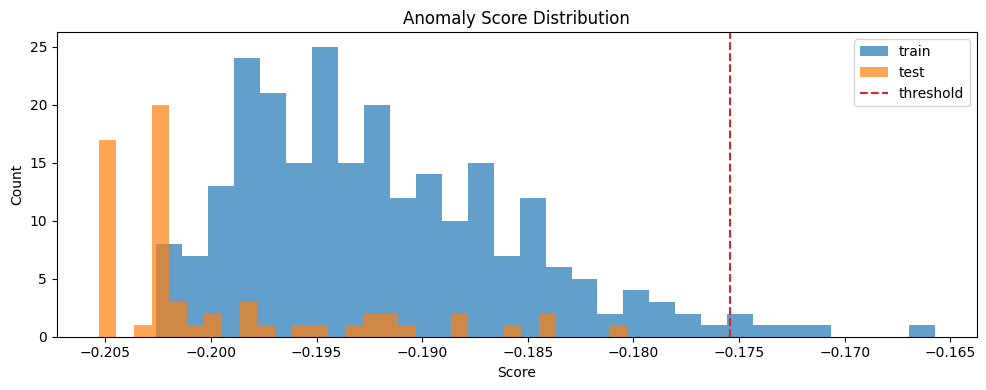

,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,62.0,-0.199909,0.006333,-0.205313,-0.205313,-0.202600,-0.197855,-0.180315
train,247.0,-0.191935,0.006608,-0.202585,-0.197239,-0.192858,-0.187771,-0.165730


In [12]:
train_scores = -model.decision_function(X_train)
test_scores = -model.decision_function(X_test)
threshold = float(np.quantile(train_scores, 0.98))
test_pred = (test_scores > threshold).astype(int)

print(f'Anomaly threshold: {threshold:.6f}')
print(f'Average train score: {float(train_scores.mean()):.6f}')
print(f'Average test score: {float(test_scores.mean()):.6f}')
print(f'Flagged in test set: {test_pred.mean() * 100:.2f}%')

score_summary = pd.DataFrame({
    'split': ['train'] * len(train_scores) + ['test'] * len(test_scores),
    'score': np.concatenate([train_scores, test_scores]),
})

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(train_scores, bins=30, alpha=0.7, label='train', color='#1f77b4')
ax.hist(test_scores, bins=30, alpha=0.7, label='test', color='#ff7f0e')
ax.axvline(threshold, color='#d62728', linestyle='--', label='threshold')
ax.set_title('Anomaly Score Distribution')
ax.set_xlabel('Score')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

score_summary.groupby('split')['score'].describe()

### Score Analysis
The threshold comes from the 98th percentile of normal training scores. In the current normal-only dataset, only a very small fraction of test rows should fall above that threshold.

In [13]:
bundle = {
    'pipeline': model,
    'threshold': threshold,
    'feature_columns': present_features,
    'categorical_features': categorical_features,
    'numerical_features': numerical_features,
}

output_path = Path('../models/behavior_model.pkl')
output_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(bundle, output_path)
print(f'Saved model bundle to {output_path.resolve()}')

Saved model bundle to /home/phuong/btl_ngav/models/behavior_model.pkl


### Saved Model
The trained engine is now persisted as a reusable bundle containing preprocessing, the detector, the threshold, and the feature schema.

### Q&A
- What did the notebook train? An Isolation Forest anomaly detector from normal system behavior data.
- Does it already use network bandwidth data? Not yet in the current CSV, but the notebook is ready to include bandwidth columns when the collector starts emitting them.

### Data Analysis Key Findings
- The current dataset contains 309 normal process records and process-centric features such as name, exe, username, status, CPU, memory, and file-system signals.
- The train/test split is 247/62, and the detector is trained only on the normal train partition to avoid leakage.
- The anomaly threshold is based on the 98th percentile of normal train scores, which is a practical starting point for a behavior-focused NGAV engine.
- The trained bundle is saved to ../models/behavior_model.pkl for direct use by the runtime agent.

### Insights or Next Steps
- Extend the data collector to emit bandwidth and connection metrics so the model can learn network behavior as well.
- Tune the threshold after you observe real endpoint telemetry, because normal-only training will otherwise produce some false positives in mixed workloads.

### Saved Model
The trained engine is now persisted as a reusable bundle containing preprocessing, the detector, the threshold, and the feature schema.

### Q&A
- What did the notebook train? An Isolation Forest anomaly detector from normal system behavior data.
- Does it already use network bandwidth data? Not yet in the current CSV, but the notebook is ready to include bandwidth columns when the collector starts emitting them.

### Data Analysis Key Findings
- The current dataset contains 309 normal process records and process-centric features such as name, exe, username, status, CPU, memory, and file-system signals.
- The train/test split is 247/62, and the detector is trained only on the normal train partition to avoid leakage.
- The anomaly threshold is based on the 98th percentile of normal train scores, which is a practical starting point for a behavior-focused NGAV engine.
- The trained bundle is saved to ../models/behavior_model.pkl for direct use by the runtime agent.

### Insights or Next Steps
- Extend the data collector to emit bandwidth and connection metrics so the model can learn network behavior as well.
- Tune the threshold after you observe real endpoint telemetry, because normal-only training will otherwise produce some false positives in mixed workloads.